In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
# Display config
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42


In [9]:
#  Load dataset 
df = pd.read_csv('hr_salary_enriched.csv')

print("DATA VALIDATION")
print("_" * 60)
print(f"Shape                : {df.shape}")
print(f"Nulls per column     :\n{df.isnull().sum()}")
print(f"Duplicate rows       : {df.duplicated().sum()}")
print(f"Duplicate Employee_ID: {df['employee_id'].duplicated().sum()}")
print(f"\nDtypes:\n{df.dtypes}")


DATA VALIDATION
____________________________________________________________
Shape                : (1000, 11)
Nulls per column     :
employee_id          0
age                  0
years_experience     0
education_level      0
job_role             0
city_tier            0
performance_score    0
num_skills           0
remote_work          0
annual_salary_usd    0
Salary_Increment     0
dtype: int64
Duplicate rows       : 0
Duplicate Employee_ID: 0

Dtypes:
employee_id           object
age                    int64
years_experience       int64
education_level       object
job_role              object
city_tier              int64
performance_score    float64
num_skills             int64
remote_work            int64
annual_salary_usd    float64
Salary_Increment     float64
dtype: object


In [6]:
# Sanity checks
assert df['employee_id'].is_unique, "Duplicate employee IDs found"
assert df['annual_salary_usd'].min() > 0, "Non-positive salaries found"
assert df['performance_score'].between(0, 5).all(), "Performance out of range"

In [7]:
df.head()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,Salary_Increment
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31,3.52
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60,2.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59,5.70
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80,5.61
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86,4.36


In [10]:
df.tail()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,Salary_Increment
995,EMP0996,37,13,Master,ML Engineer,2,3.4,11,0,127579.68,4.27
996,EMP0997,27,5,PhD,Product Manager,3,4.5,6,1,96672.53,7.48
997,EMP0998,33,10,Bachelor,Software Engineer,3,4.2,9,1,107247.32,5.96
998,EMP0999,33,9,High School,DevOps,3,4.8,5,0,100412.67,5.61
999,EMP1000,40,20,Bachelor,DevOps,2,5.0,10,0,156563.24,7.12


In [11]:
df.head(25)

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,Salary_Increment
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31,3.52
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60,2.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59,5.70
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80,5.61
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86,4.36
5,EMP0006,24,3,Master,Data Analyst,1,4.6,8,1,109682.21,5.34
6,EMP0007,51,29,Bachelor,Product Manager,2,2.6,6,0,155103.12,5.35
7,EMP0008,37,16,PhD,DevOps,2,5.0,12,0,146648.13,7.21
8,EMP0009,42,22,Bachelor,Data Analyst,2,3.2,3,0,141824.61,3.73
9,EMP0010,42,21,PhD,DevOps,3,3.4,6,0,134712.86,5.07


In [ ]:
# Overall descriptive statistics
numeric_cols = ['age', 'years_experience', 'performance_score',
                'num_skills', 'annual_salary_usd', 'Salary_Increment']
print("DESCRIPTIVE STATISTICS — NUMERIC COLUMNS")

print("_" * 60)
df[numeric_cols].describe().round(2)

DESCRIPTIVE STATISTICS — NUMERIC COLUMNS
____________________________________________________________


,age,years_experience,performance_score,num_skills,annual_salary_usd,Salary_Increment
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,40.67,18.62,3.51,7.16,137295.11,4.65
std,11.54,11.63,0.86,3.10,34692.97,1.45
min,22.00,0.00,2.00,2.00,66716.64,0.59
25%,30.00,8.00,2.80,4.00,107616.09,3.61
50%,41.00,19.00,3.50,7.00,137537.96,4.62
75%,51.00,29.00,4.30,10.00,164807.11,5.69
max,60.00,40.00,5.00,12.00,217067.54,8.80


In [24]:
# jobs in datasets
unique_job_roles = df['job_role'].unique()
unique_job_roles


array(['Software Engineer', 'ML Engineer', 'Data Analyst', 'DevOps',
       'Product Manager', 'QA Engineer'], dtype=object)

In [25]:
# Salary by Job Role
role_stats = df.groupby('job_role')['annual_salary_usd'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(0).sort_values('mean', ascending=False)


print("SALARY BY JOB ROLE")
print("_" * 60)
role_stats

SALARY BY JOB ROLE
____________________________________________________________


,count,mean,median,std,min,max
job_role,,,,,,
DevOps,190,140246.0,138305.0,34183.0,67406.0,213998.0
ML Engineer,147,140148.0,142054.0,33525.0,70602.0,207092.0
QA Engineer,165,137707.0,136606.0,35851.0,66717.0,209754.0
Software Engineer,152,135379.0,140279.0,33942.0,70504.0,203840.0
Data Analyst,178,135237.0,136070.0,35088.0,69836.0,217068.0
Product Manager,168,134972.0,132747.0,35435.0,70735.0,205695.0


In [27]:
#  Salary by City Tier and Education Level
print("SALARY BY CITY TIER  (1 = Metro, 3 = Small city)")
print("_" * 60)
tier_stats = df.groupby('city_tier')['annual_salary_usd'].agg(
    ['count', 'mean', 'median', 'std']
).round(0)
print(tier_stats)

print("\n" + "_" * 60)
print("SALARY BY EDUCATION LEVEL")
print("_" * 60)
edu_stats = df.groupby('education_level')['annual_salary_usd'].agg(
    ['count', 'mean', 'median', 'std']
).round(0).sort_values('mean', ascending=False)
print(edu_stats)

SALARY BY CITY TIER  (1 = Metro, 3 = Small city)
____________________________________________________________
           count      mean    median      std
city_tier                                    
1            319  148736.0  149272.0  34759.0
2            316  135968.0  138107.0  33960.0
3            365  128446.0  126954.0  32481.0

____________________________________________________________
SALARY BY EDUCATION LEVEL
____________________________________________________________
                 count      mean    median      std
education_level                                    
PhD                256  143086.0  144088.0  33873.0
Master             246  137630.0  133556.0  35086.0
Bachelor           258  136005.0  135116.0  34486.0
High School        240  132161.0  133454.0  34665.0


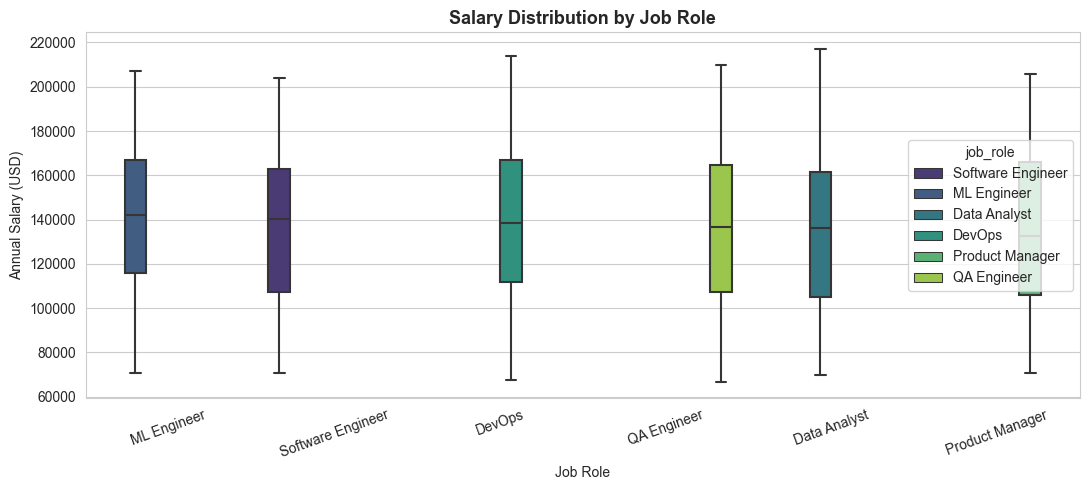

In [30]:
#  Box plot: Salary by Job Role
plt.figure(figsize=(11, 5))
order = df.groupby('job_role')['annual_salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='job_role', y='annual_salary_usd', order=order,
            palette='viridis', hue='job_role')
plt.title('Salary Distribution by Job Role', fontsize=13, fontweight='bold')
plt.xlabel('Job Role')
plt.ylabel('Annual Salary (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('viz1_salary_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

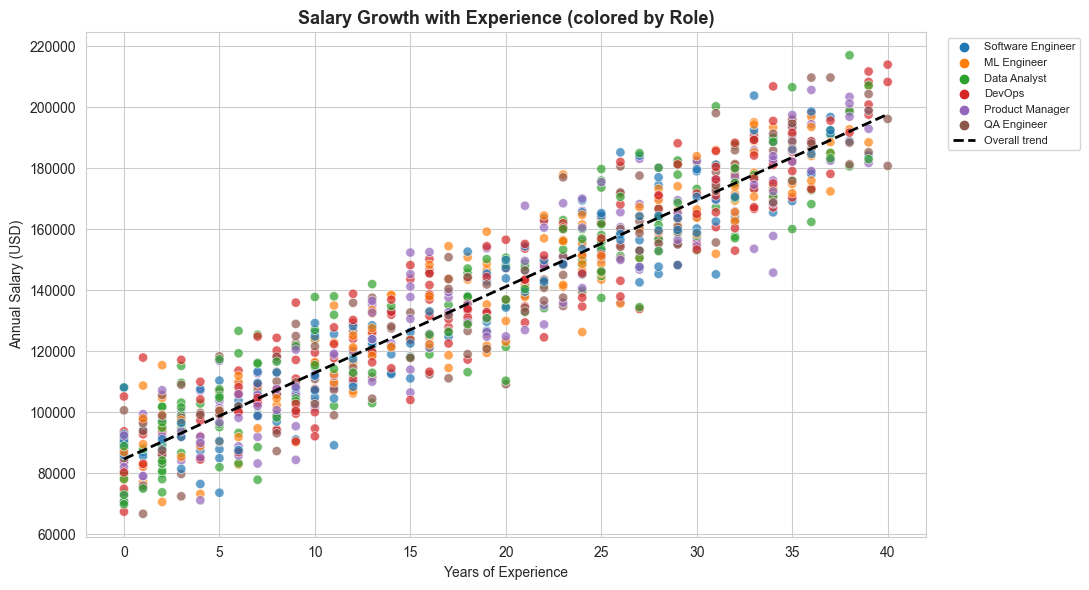

In [32]:
# Scatter: Experience vs Salary, colored by Role


plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x='years_experience', y='annual_salary_usd',
                hue='job_role', alpha=0.7, s=45, palette='tab10')

# Overall trend line
z = np.polyfit(df['years_experience'], df['annual_salary_usd'], 1)
p = np.poly1d(z)
xs = np.linspace(df['years_experience'].min(), df['years_experience'].max(), 100)
plt.plot(xs, p(xs), 'k--', linewidth=2, label='Overall trend')

plt.title('Salary Growth with Experience (colored by Role)', fontsize=13, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Annual Salary (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('viz2_experience_vs_salary.png', dpi=150, bbox_inches='tight')
plt.show()

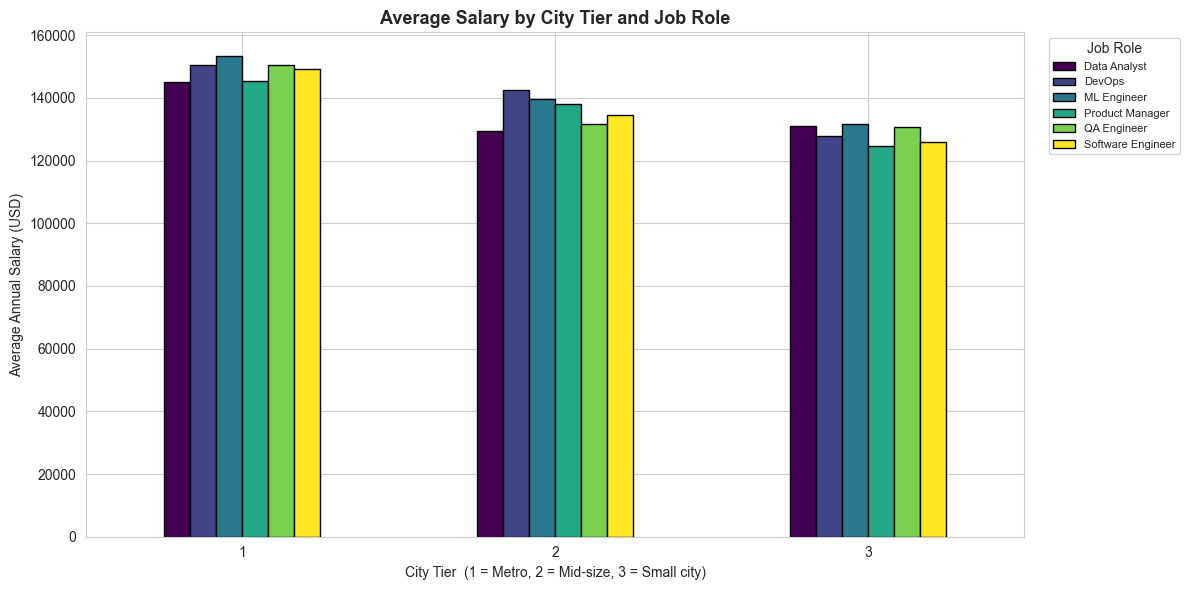

In [33]:
#  Bar chart: Avg Salary by City Tier, grouped by Role
plt.figure(figsize=(12, 6))
pivot = df.pivot_table(values='annual_salary_usd', index='city_tier',
                       columns='job_role', aggfunc='mean')
pivot.plot(kind='bar', ax=plt.gca(), colormap='viridis', edgecolor='black')
plt.title('Average Salary by City Tier and Job Role', fontsize=13, fontweight='bold')
plt.xlabel('City Tier  (1 = Metro, 2 = Mid-size, 3 = Small city)')
plt.ylabel('Average Annual Salary (USD)')
plt.xticks(rotation=0)
plt.legend(title='Job Role', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('viz3_salary_by_city_tier.png', dpi=150, bbox_inches='tight')
plt.show()

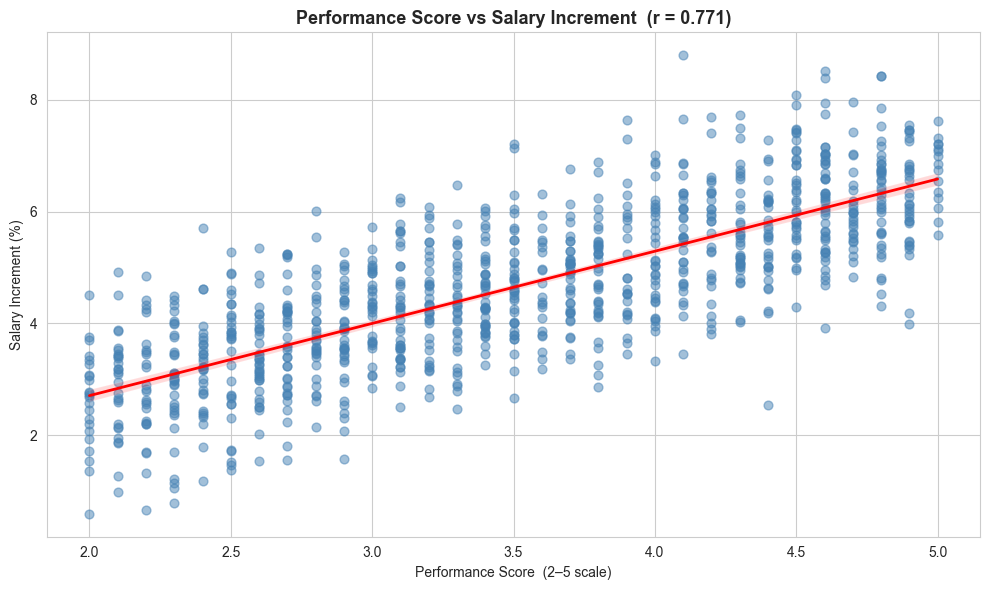

Pearson correlation: 0.771
Interpretation: STRONG positive relationship


In [34]:
# Scatter: Performance vs Salary Increment
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='performance_score', y='Salary_Increment',
            scatter_kws={'alpha': 0.5, 's': 40, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})

r = df['Salary_Increment'].corr(df['performance_score'])
plt.title(f'Performance Score vs Salary Increment  (r = {r:.3f})',
          fontsize=13, fontweight='bold')
plt.xlabel('Performance Score  (2–5 scale)')
plt.ylabel('Salary Increment (%)')
plt.tight_layout()
plt.savefig('viz4_performance_vs_increment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson correlation: {r:.3f}")
print("Interpretation: STRONG positive relationship" if r > 0.6
      else "Interpretation: MODERATE relationship" if r > 0.3
      else "Interpretation: WEAK relationship")

In [35]:
# Cell 10: Encode categoricals for Linear Regression
model_df = df.copy()

# One-hot encode categorical features
model_df = pd.get_dummies(model_df,
                          columns=['job_role', 'education_level'],
                          drop_first=True)

# Features — drop target, ID, and increment (not used to predict salary)
feature_cols = [c for c in model_df.columns
                if c not in ['employee_id', 'annual_salary_usd', 'Salary_Increment']]

X = model_df[feature_cols].astype(float)
y = model_df['annual_salary_usd']

print(f"Features used ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  • {c}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features used (14):
  • age
  • years_experience
  • city_tier
  • performance_score
  • num_skills
  • remote_work
  • job_role_DevOps
  • job_role_ML Engineer
  • job_role_Product Manager
  • job_role_QA Engineer
  • job_role_Software Engineer
  • education_level_High School
  • education_level_Master
  • education_level_PhD

X shape: (1000, 14)
y shape: (1000,)


In [36]:
# Train Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained ✔")
print(f"Intercept: ${model.intercept_:,.0f}")
print("\nCoefficients (top 10 by |value|):")
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_
}).sort_values('coef', key=abs, ascending=False)
coef_df.head(10)

Model trained ✔
Intercept: $67,216

Coefficients (top 10 by |value|):


,feature,coef
2,city_tier,-8033.171800
13,education_level_PhD,6271.750989
3,performance_score,6142.958170
11,education_level_High School,-3935.000230
5,remote_work,3196.327772
12,education_level_Master,2930.737101
1,years_experience,2741.897314
4,num_skills,1236.541586
9,job_role_QA Engineer,-437.032557
8,job_role_Product Manager,-200.713705


MODEL EVALUATION — Test Set
R²   : 0.9854   (98.5% of variance explained)
MAE  : $3,525
RMSE : $4,382


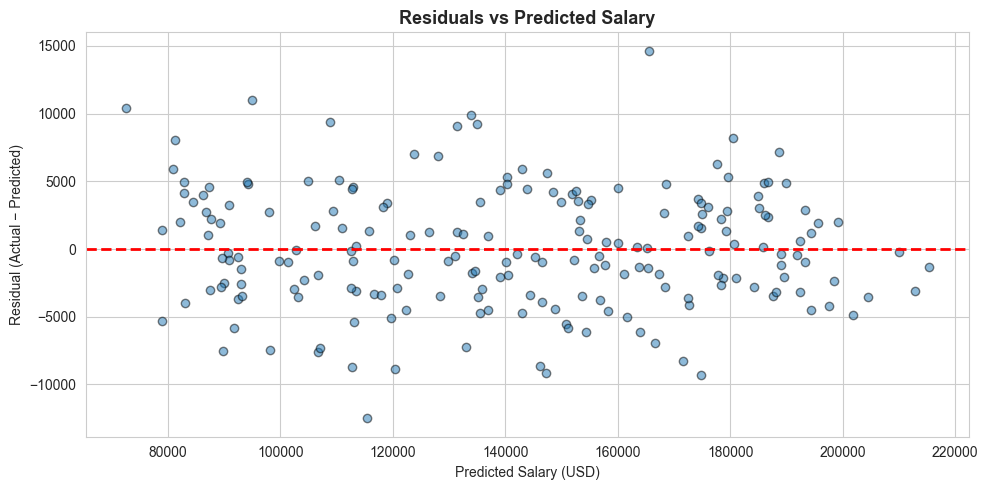

In [37]:
# Evaluate model on test set
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 60)
print("MODEL EVALUATION — Test Set")
print("=" * 60)
print(f"R²   : {r2:.4f}   ({r2*100:.1f}% of variance explained)")
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted Salary', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Salary (USD)')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.savefig('viz5_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
#  Identify over/underpaid employees via residuals (full dataset)
df['predicted_salary'] = model.predict(X)
df['residual'] = df['annual_salary_usd'] - df['predicted_salary']
df['residual_pct'] = (df['residual'] / df['predicted_salary'] * 100).round(1)

# Threshold: ±2 standard deviations of residual
res_std = df['residual'].std()
threshold = 2 * res_std

overpaid  = df[df['residual'] >  threshold].sort_values('residual', ascending=False)
underpaid = df[df['residual'] < -threshold].sort_values('residual')

print("=" * 60)
print(f"OUTLIERS — |residual| > 2σ  (σ = ${res_std:,.0f})")
print("=" * 60)
print(f"Overpaid  employees: {len(overpaid)}")
print(f"Underpaid employees: {len(underpaid)}")

cols = ['employee_id', 'job_role', 'years_experience', 'education_level',
        'city_tier', 'performance_score', 'annual_salary_usd',
        'predicted_salary', 'residual_pct']

print("\nTOP 10 OVERPAID:")
print(overpaid[cols].head(10).to_string(index=False))

print("\nTOP 10 UNDERPAID:")
print(underpaid[cols].head(10).to_string(index=False))

OUTLIERS — |residual| > 2σ  (σ = $4,117)
Overpaid  employees: 25
Underpaid employees: 24

TOP 10 OVERPAID:
employee_id        job_role  years_experience education_level  city_tier  performance_score  annual_salary_usd  predicted_salary  residual_pct
    EMP0320    Data Analyst                28          Master          2                4.6          180185.09     165539.670593           8.8
    EMP0798          DevOps                33             PhD          3                4.0          184185.12     171114.314946           7.6
    EMP0577    Data Analyst                39          Master          1                2.5          207157.91     194573.563918           6.5
    EMP0899     QA Engineer                 2     High School          3                2.5           86132.61      74547.180636          15.5
    EMP0682    Data Analyst                 9     High School          3                2.0          103649.64      92101.127634          12.5
    EMP0235     QA Engineer        

In [39]:
# Performance vs Increment — correlation + regression
from scipy.stats import pearsonr

r, p = pearsonr(df['performance_score'], df['Salary_Increment'])
print("=" * 60)
print("PERFORMANCE ↔ SALARY INCREMENT")
print("=" * 60)
print(f"Pearson r : {r:.3f}")
print(f"p-value   : {p:.2e}")
print(f"R²        : {r**2:.3f}  ({r**2*100:.1f}% of increment variance explained by performance)")

# Compare average increment across performance bands
df['perf_band'] = pd.cut(df['performance_score'],
                         bins=[1.99, 2.5, 3.5, 4.5, 5.0],
                         labels=['Low (2.0–2.5)', 'Mid (2.5–3.5)',
                                 'High (3.5–4.5)', 'Top (4.5–5.0)'])
band_stats = df.groupby('perf_band', observed=True)['Salary_Increment'].agg(
    ['count', 'mean', 'std', 'min', 'max']
).round(2)
print("\nIncrement by Performance Band:")
print(band_stats)

PERFORMANCE ↔ SALARY INCREMENT
Pearson r : 0.771
p-value   : 7.66e-198
R²        : 0.595  (59.5% of increment variance explained by performance)

Increment by Performance Band:
                count  mean   std   min   max
perf_band                                    
Low (2.0–2.5)     172  3.02  0.99  0.59  5.71
Mid (2.5–3.5)     357  4.11  0.97  1.54  7.21
High (3.5–4.5)    314  5.36  1.06  2.54  8.80
Top (4.5–5.0)     157  6.25  0.90  3.92  8.52


In [40]:
# High performers with low increments (and vice versa)
perf_q25 = df['performance_score'].quantile(0.25)
perf_q75 = df['performance_score'].quantile(0.75)
inc_q25  = df['Salary_Increment'].quantile(0.25)
inc_q75  = df['Salary_Increment'].quantile(0.75)

mismatch_low = df[(df['performance_score'] >= perf_q75) &
                  (df['Salary_Increment'] <= inc_q25)]

mismatch_high = df[(df['performance_score'] <= perf_q25) &
                   (df['Salary_Increment'] >= inc_q75)]

print("=" * 60)
print("PERFORMANCE–INCREMENT MISMATCH")
print("=" * 60)
print(f"\nHigh performers (perf ≥ {perf_q75}) with LOW increment (≤ {inc_q25}): {len(mismatch_low)}")
print(f"Low performers  (perf ≤ {perf_q25}) with HIGH increment (≥ {inc_q75}): {len(mismatch_high)}")

print("\nSample — High performer, low raise:")
print(mismatch_low[['employee_id', 'job_role', 'performance_score',
                    'Salary_Increment', 'annual_salary_usd']].head(8).to_string(index=False))

print("\nSample — Low performer, high raise:")
print(mismatch_high[['employee_id', 'job_role', 'performance_score',
                     'Salary_Increment', 'annual_salary_usd']].head(8).to_string(index=False))

PERFORMANCE–INCREMENT MISMATCH

High performers (perf ≥ 4.3) with LOW increment (≤ 3.6075): 1
Low performers  (perf ≤ 2.8) with HIGH increment (≥ 5.692500000000001): 2

Sample — High performer, low raise:
employee_id    job_role  performance_score  Salary_Increment  annual_salary_usd
    EMP0263 QA Engineer                4.4              2.54          145602.09

Sample — Low performer, high raise:
employee_id     job_role  performance_score  Salary_Increment  annual_salary_usd
    EMP0221  ML Engineer                2.4              5.71          171586.31
    EMP0479 Data Analyst                2.8              6.01           94909.17


In [41]:
#  Location pay gap — same role, different city tier
print("=" * 60)
print("LOCATION PAY GAP (same role, different city tier)")
print("=" * 60)

loc_pivot = df.pivot_table(values='annual_salary_usd',
                           index='job_role', columns='city_tier',
                           aggfunc='mean').round(0)
loc_pivot.columns = [f'Tier {c}' for c in loc_pivot.columns]
loc_pivot['Gap %'] = ((loc_pivot.max(axis=1) - loc_pivot.min(axis=1))
                      / loc_pivot.min(axis=1) * 100).round(1)
print(loc_pivot)

LOCATION PAY GAP (same role, different city tier)
                     Tier 1    Tier 2    Tier 3  Gap %
job_role                                              
Data Analyst       145020.0  129483.0  130898.0   12.0
DevOps             150395.0  142483.0  127682.0   17.8
ML Engineer        153231.0  139550.0  131629.0   16.4
Product Manager    145324.0  137888.0  124631.0   16.6
QA Engineer        150359.0  131743.0  130801.0   15.0
Software Engineer  149105.0  134576.0  125764.0   18.6
